In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/cig_ps.zip" -d /content/cig_ps
!ls /content/cig_ps/cig_ps


Mounted at /content/drive
test_images  train_images  train-labels.csv


In [ ]:
!pip install -q albumentations --upgrade


In [ ]:
import os
import math
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List
from collections import Counter

import editdistance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torchvision import transforms
from PIL import Image
import albumentations as A
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = device
print(f"Device      : {device}")
if device.type == 'cuda':
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device      : cuda
GPU         : Tesla T4
VRAM        : 15.6 GB


## 2. Dataset Paths

In [ ]:
TRAIN_IMAGE_DIR = '/content/cig_ps/cig_ps/train_images'
TEST_IMAGE_DIR  = '/content/cig_ps/cig_ps/test_images'
TRAIN_LABEL_CSV = '/content/cig_ps/cig_ps/train-labels.csv'

df = pd.read_csv(TRAIN_LABEL_CSV)
print(f"\nLabel CSV shape  : {df.shape}")
print(f"Label CSV columns: {list(df.columns)}")
df.head()



Label CSV shape  : (20000, 3)
Label CSV columns: ['Unnamed: 0', 'image', 'text']


,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


## 3a. Image Cleaning Journey — What We Tried Before the Final Pipeline

Before settling on the morphological + dual-channel approach used in this notebook, a series of progressively more sophisticated denoising and blob-removal strategies were explored. This section documents that journey so the design decisions in the final pipeline make sense in context.

---

### The Problem: Noisy Images with Ink Blobs

The cigarette-pack images contain two distinct artefacts that make OCR difficult:

1. **Speckle noise** — small isolated high-intensity pixels scattered around the text strokes.
2. **Ink blobs** — large, irregular dark regions that sometimes physically connect to (or overlap with) text characters, making it hard to separate text from background.

---

### Attempt 1 — Morphological Operations (Dilation & Erosion)

The first approach was classical morphological processing:

- **Dilation** expands foreground pixels, which thickens strokes and connects nearby broken fragments.
- **Erosion** (applied after dilation, forming a **morphological closing**) shrinks them back, removing isolated small noise blobs that dilation could not absorb.

**Result:** Morphological closing was *successfully* removed speckle noise around the text. It also provided a minor, partial break in the connection between blob regions and text strokes. However, the blobs themselves remained, and — critically — the contours of the text and blob were still joined after morphological cleaning, making contour-based masking unreliable.

---

### Attempt 2 — Contour-Based Blob Removal

With the morphologically cleaned image, connected-component / contour analysis was attempted:

- Find all contours in the binary image.
- Compute each contour's area.
- Remove contours whose area exceeds a threshold (assumed to be blobs, not characters).

**Result:** Failed. Because the morphological operations could not fully sever the text–blob connection, the blob contour merged with adjacent character contours. When the large contour was masked out, the text pixels inside it were also erased — destroying the very information we needed to read.

---

### Attempt 3 — Segmentation with Pretrained Models (ESRGAN + SAM)

To achieve a cleaner separation, a two-stage deep-learning segmentation pipeline was tried:

1. **ESRGAN super-resolution** — upscale the noisy image to reduce pixel-level blockiness, aiming to produce smoother edges that a segmentation model could work with more reliably.
2. **SAM (Segment Anything Model)** — run pretrained SAM on the upscaled image to segment and isolate the blob, then remove it.

**Result:** The upscaling step faithfully reproduced the noise at higher resolution — the speckle and blob structure were preserved (and in some cases amplified) in the upscaled image. SAM merged the noisy marks with surrounding regions and could not cleanly delineate the blob boundary. Blob removal was unsuccessful.

---

### Final Approach — Two-Channel Input (Morphed Image + Gradient)

Rather than continuing to fight the blob in preprocessing, the strategy was shifted: **give the model more information** so it can learn to ignore the blob on its own.

The key insight: a Sobel gradient image highlights *edges and stroke boundaries*, which are strongly present along character contours but weaker in the interior of large flat blobs. By stacking:

- **Channel 0** — the morphologically cleaned grayscale image (global shape / intensity)  
- **Channel 1** — the Sobel gradient of the cleaned image (local edge / stroke information)

…into a single 2-channel tensor, the model receives two complementary views of the same image. The CNN backbone can learn to weight these channels appropriately — relying on edges to detect character strokes even where the intensity channel is corrupted by blob overlap.

This is the pipeline implemented in **Section 3** and used throughout the rest of the notebook.

---


## 3b. Preprocessing Helper Functions


In [ ]:
def dilate_image(img: np.ndarray, ksize_x: int = 3, ksize_y: int = 1, iterations: int = 1) -> np.ndarray:
    """
    Morphological dilation — expands bright (foreground) pixels.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize_x, ksize_y))
    return cv2.dilate(img, kernel, iterations=iterations)


def erode_image(img: np.ndarray, ksize_x: int = 3, ksize_y: int = 1, iterations: int = 1) -> np.ndarray:
    """
    Morphological erosion — shrinks bright (foreground) pixels.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize_x, ksize_y))
    return cv2.erode(img, kernel, iterations=iterations)


def gaussian_blur_image(img: np.ndarray, kernel_size: int = 3, sigma: float = 0.0) -> np.ndarray:
    """
    Gaussian blur to suppress high-frequency noise.
    """
    if kernel_size % 2 == 0:
        kernel_size += 1
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)


def compute_gradient(img: np.ndarray, ksize: int = 3) -> np.ndarray:
    """
    Sobel gradient magnitude — highlights character stroke edges.
    """
    img_f  = img.astype(np.float32)
    grad_x = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=ksize)
    grad_y = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=ksize)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)

    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return magnitude.astype(np.uint8)


## 4 Albumentations Augmentation Transform


In [ ]:
train_transform = A.Compose([
    A.ShiftScaleRotate(
        shift_limit  = 0.02,
        scale_limit  = 0.05,
        rotate_limit = 3,
        border_mode  = cv2.BORDER_REPLICATE,
        p            = 0.5
    ),
    A.Perspective(
        scale = (0.02, 0.05),
        p     = 0.3
    ),

    A.GaussNoise(
        std_range = (0.05, 0.15),
        p         = 0.3
    ),
    A.RandomBrightnessContrast(
        brightness_limit = 0.1,
        contrast_limit   = 0.1,
        p                = 0.3
    ),
])

val_transform = None



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 5 `RawOCRDataset` — PyTorch Dataset Class



In [ ]:
class RawOCRDataset(Dataset):
    """
    PyTorch Dataset for OCR sequence recognition.
    """

    def __init__(
      self,
      image_dir,
      label_file     = None,
      target_size    = (32, 128),
      dilate_ksize_x = 3,
      dilate_ksize_y = 1,
      dilate_iters   = 1,
      erode_ksize_x  = 3,
      erode_ksize_y  = 1,
      erode_iters    = 1,
      blur_ksize     = 3,
      blur_sigma     = 0.0,
      grad_ksize     = 3,
      transform      = None,
      start_idx      = None,
      end_idx        = None,
  ):
      super().__init__()

      self.image_dir     = Path(image_dir)
      self.target_size   = target_size

      self.dilate_ksize_x = dilate_ksize_x
      self.dilate_ksize_y = dilate_ksize_y
      self.dilate_iters   = dilate_iters
      self.erode_ksize_x  = erode_ksize_x
      self.erode_ksize_y  = erode_ksize_y
      self.erode_iters    = erode_iters
      self.blur_ksize     = blur_ksize
      self.blur_sigma     = blur_sigma
      self.grad_ksize     = grad_ksize
      self.transform      = transform


      self.image_paths = sorted([
          p for p in self.image_dir.iterdir()
      ])


      if start_idx is not None or end_idx is not None:
          self.image_paths = self.image_paths[start_idx:end_idx]

      assert len(self.image_paths) > 0, f"No images found in {image_dir}"
      self.labels = {}

      if label_file is not None:
          df = pd.read_csv(label_file)

          required = {"image", "text"}
          if not required.issubset(df.columns):
              raise ValueError(
                  f"CSV must have columns {required}, got {list(df.columns)}"
              )

          for _, row in df.iterrows():
              stem = Path(str(row["image"])).stem
              self.labels[stem] = str(row["text"])

      print(
          f"[RawOCRDataset] {len(self.image_paths)} images | "
          f"{len(self.labels)} labels loaded"
      )

    def _preprocess(self, img_bgr: np.ndarray):
        """
        Full preprocessing pipeline.  Returns (blurred, gradient) both uint8.
        """
        if len(img_bgr.shape) == 3:
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        else:
            gray = img_bgr.copy()


        if self.transform is not None:
            gray = self.transform(image=gray)["image"]

        dilated = dilate_image(gray,    self.dilate_ksize_x, self.dilate_ksize_y, self.dilate_iters)
        eroded  = erode_image(dilated,  self.erode_ksize_x,  self.erode_ksize_y,  self.erode_iters)

        gradient = compute_gradient(eroded, self.grad_ksize)

        if self.target_size is not None:
            h, w = self.target_size
            eroded = cv2.resize(eroded, (w, h), interpolation=cv2.INTER_LINEAR)
            gradient = cv2.resize(gradient, (w, h), interpolation=cv2.INTER_LINEAR)


        return eroded, gradient

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        path    = self.image_paths[idx]
        img_bgr = cv2.imread(str(path))
        if img_bgr is None:
            raise FileNotFoundError(f"cv2.imread failed: {path}")

        eroded, gradient = self._preprocess(img_bgr)


        image = torch.stack([
            torch.from_numpy(eroded).float()  / 255.0,
            torch.from_numpy(gradient).float() / 255.0,
        ], dim=0)

        label = self.labels.get(path.stem, "")

        return {
            "image": image,
            "label": label,
            "path" : str(path),
        }


    def get_stages(self, idx: int) -> dict:
        """
        Return a dict of every intermediate preprocessing stage as numpy arrays.
        Useful for visualization / debugging.
        """
        path    = self.image_paths[idx]
        img_bgr = cv2.imread(str(path))
        if img_bgr is None:
            raise FileNotFoundError(f"cv2.imread failed: {path}")

        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        if self.target_size is not None:
            h, w = self.target_size
            gray = cv2.resize(gray, (w, h), interpolation=cv2.INTER_LINEAR)

        # No augmentation in visualization — want deterministic stages
        dilated  = dilate_image(gray,   self.dilate_ksize_x, self.dilate_ksize_y, self.dilate_iters)
        eroded   = erode_image(dilated, self.erode_ksize_x,  self.erode_ksize_y,  self.erode_iters)
        gradient = compute_gradient(eroded, self.grad_ksize)

        return {
            "original": cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
            "gray"    : gray,
            "dilated" : dilated,
            "eroded"  : eroded,
            "gradient": gradient,
        }



## 6. Collate Function & Visualization Helper

In [ ]:

class Charset:
    """Builds vocabulary from training labels and provides encode/decode."""

    def __init__(self, texts: List[str]):
        chars = sorted(set(''.join(texts)))
        self.chars     = ['<blank>'] + chars
        self.char2idx  = {c: i for i, c in enumerate(self.chars)}
        self.blank_idx = 0

    @property
    def num_classes(self) -> int:
        return len(self.chars)

    def encode(self, text: str) -> List[int]:
        return [self.char2idx[c] for c in text if c in self.char2idx]

    def decode_indices(self, indices: List[int]) -> str:
        out, prev = [], None
        for idx in indices:
            if idx != prev:
                if idx != self.blank_idx:
                    out.append(self.chars[idx])
            prev = idx
        return ''.join(out)


def build_charset(label_csv: str) -> Charset:
    df = pd.read_csv(label_csv)
    texts = df['text'].astype(str).tolist()
    cs = Charset(texts)
    print(f"[Charset] {cs.num_classes} classes (incl. blank) | vocab: {''.join(cs.chars[1:])}")
    return cs

def make_ctc_collate(charset: Charset):
    def collate_fn(batch):
        images     = torch.stack([b['image'] for b in batch])
        texts      = [b['label'] for b in batch]
        paths      = [b['path']  for b in batch]


        encoded    = [charset.encode(t) for t in texts]
        labels     = torch.tensor([idx for seq in encoded for idx in seq],
                                   dtype=torch.long)
        label_lens = torch.tensor([len(seq) for seq in encoded], dtype=torch.long)

        return {
            'images'    : images,
            'labels'    : labels,
            'label_lens': label_lens,
            'texts'     : texts,
            'paths'     : paths,
        }
    return collate_fn

def collate_fn_viz(batch):
    """Non-CTC collate kept for visualization cells that use batch['image']."""
    images = torch.stack([b['image'] for b in batch])
    labels = [b['label'] for b in batch]
    paths  = [b['path']  for b in batch]
    return {'image': images, 'label': labels, 'path': paths}


def visualize_pipeline(dataset, indices=None, figsize=(20, 4)):
    if indices is None:
        indices = list(range(min(3, len(dataset))))
    stage_keys   = ["original", "gray", "dilated", "eroded", "gradient"]
    stage_titles = ["Original", "Gray + Resize", "Dilated", "Eroded", "Gradient → Ch1"]
    for idx in indices:
        stages = dataset.get_stages(idx)
        label  = dataset.labels.get(dataset.image_paths[idx].stem, "N/A")
        fig, axes = plt.subplots(1, len(stage_keys), figsize=figsize)
        fig.suptitle(f'Sample {idx}  |  Label: "{label}"', fontsize=13, fontweight='bold')
        for ax, key, title in zip(axes, stage_keys, stage_titles):
            img = stages[key]
            ax.imshow(img, cmap=None if key == "original" else "gray")
            ax.set_title(title, fontsize=9); ax.axis('off')
        plt.tight_layout(); plt.show()




## 7 Instantiate Train & Validation Datasets




In [ ]:
train_dataset = RawOCRDataset(
    image_dir      = TRAIN_IMAGE_DIR,
    label_file     = TRAIN_LABEL_CSV,
    target_size    = (100, 200),
    dilate_ksize_x = 3,
    dilate_ksize_y = 1,
    dilate_iters   = 1,
    erode_ksize_x  = 3,
    erode_ksize_y  = 1,
    erode_iters    = 1,
    blur_ksize     = 0,
    blur_sigma     = 0.0,
    grad_ksize     = 3,
    transform      = train_transform,
    start_idx=0,
    end_idx=18000,
)

val_dataset = RawOCRDataset(
    image_dir   = TRAIN_IMAGE_DIR,
    label_file  = TRAIN_LABEL_CSV,
    target_size = (100, 200),
    transform   = None,
    start_idx=18000,
    end_idx=20000,
)




[RawOCRDataset] 18000 images | 20000 labels loaded
[RawOCRDataset] 2000 images | 20000 labels loaded


## 8. DataLoaders

In [ ]:
charset = build_charset(TRAIN_LABEL_CSV)
ctc_collate = make_ctc_collate(charset)

BATCH_SIZE  = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    collate_fn  = ctc_collate,
    pin_memory  = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    collate_fn  = ctc_collate,
    pin_memory  = True,
)



[Charset] 39 classes (incl. blank) | vocab: +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar


## 9. Visualize Preprocessing Pipeline

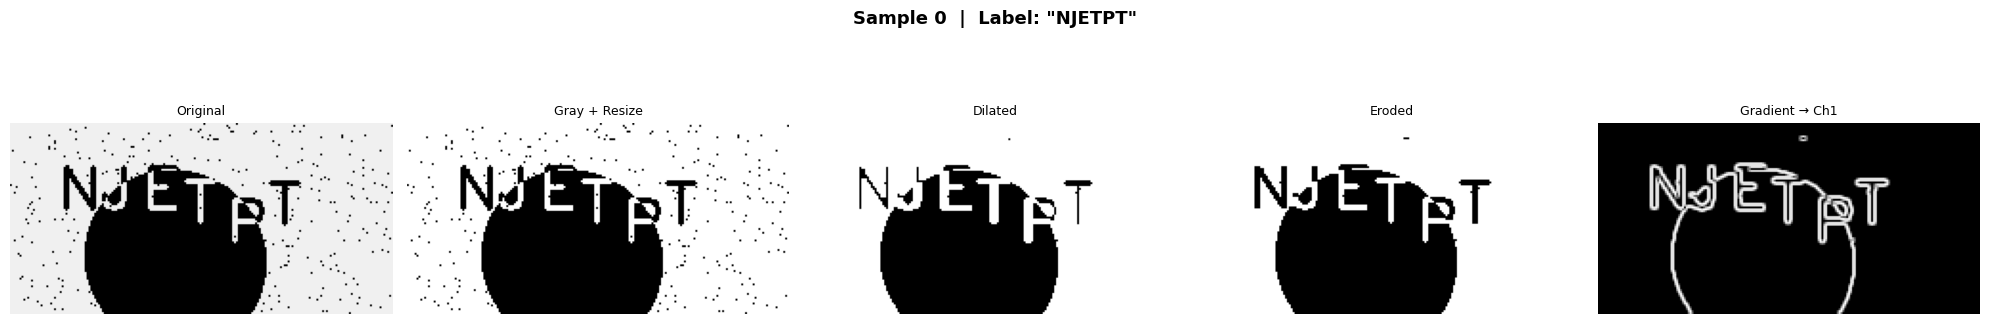

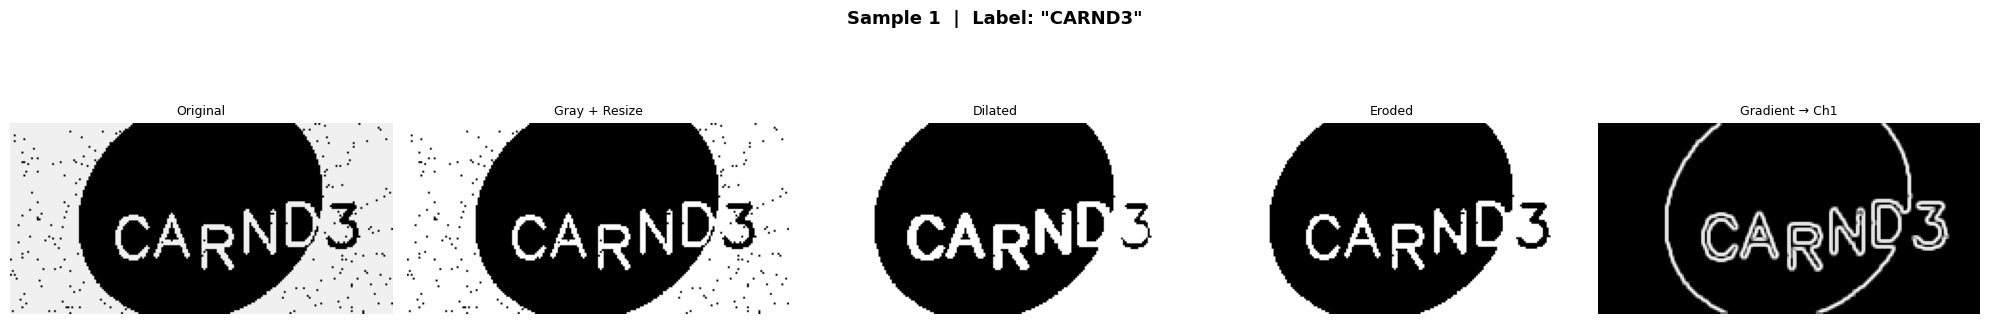

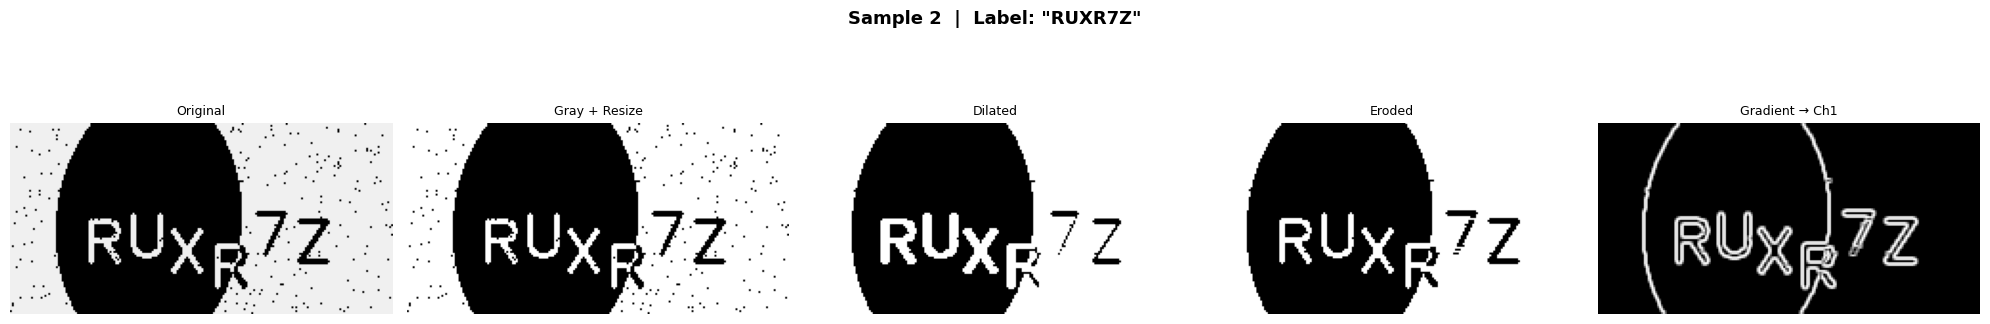

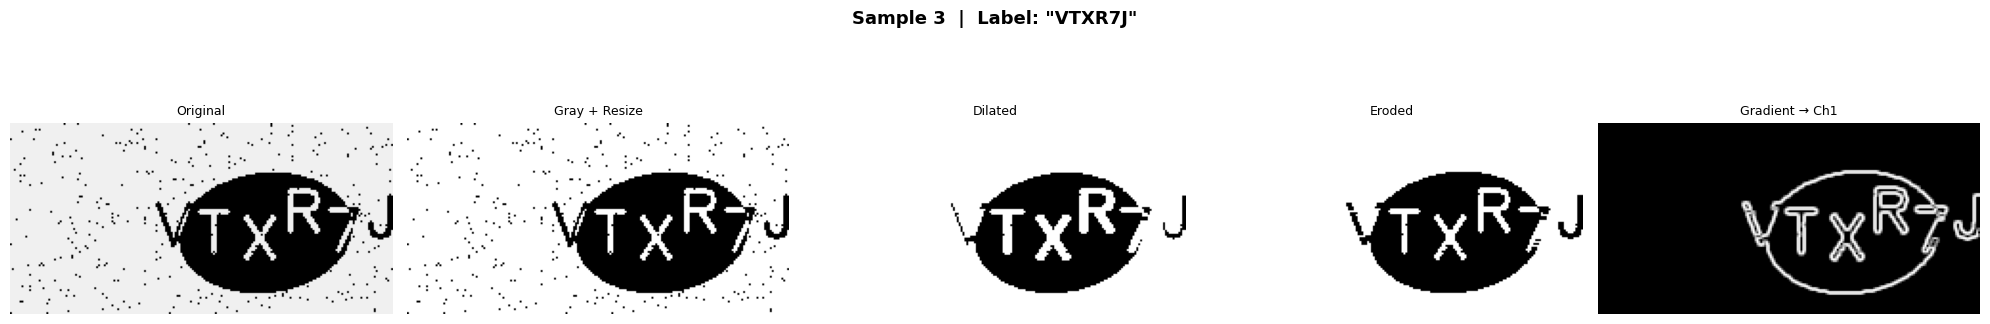

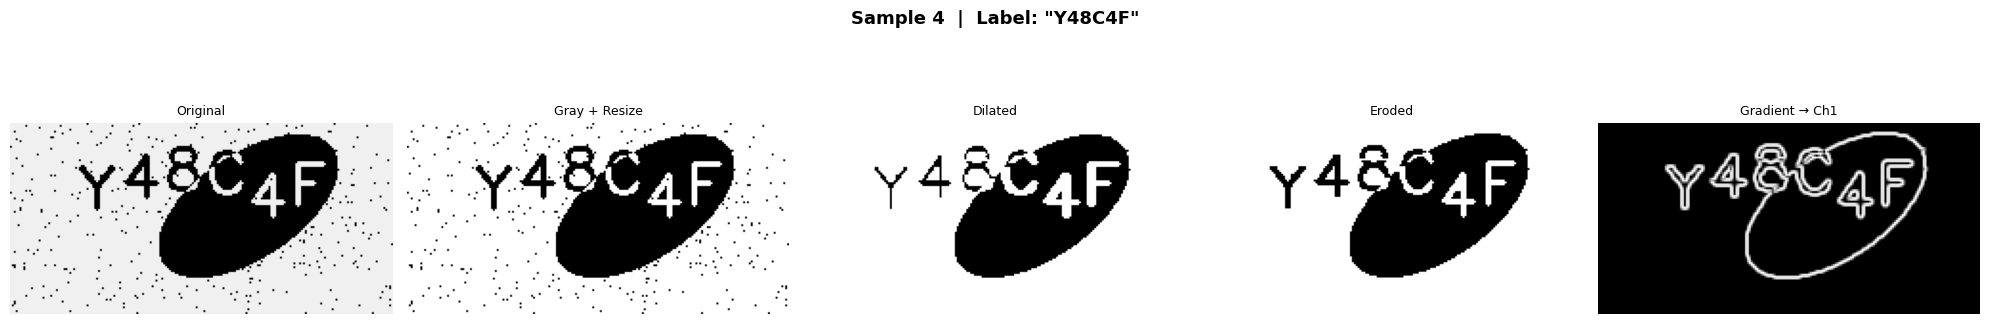

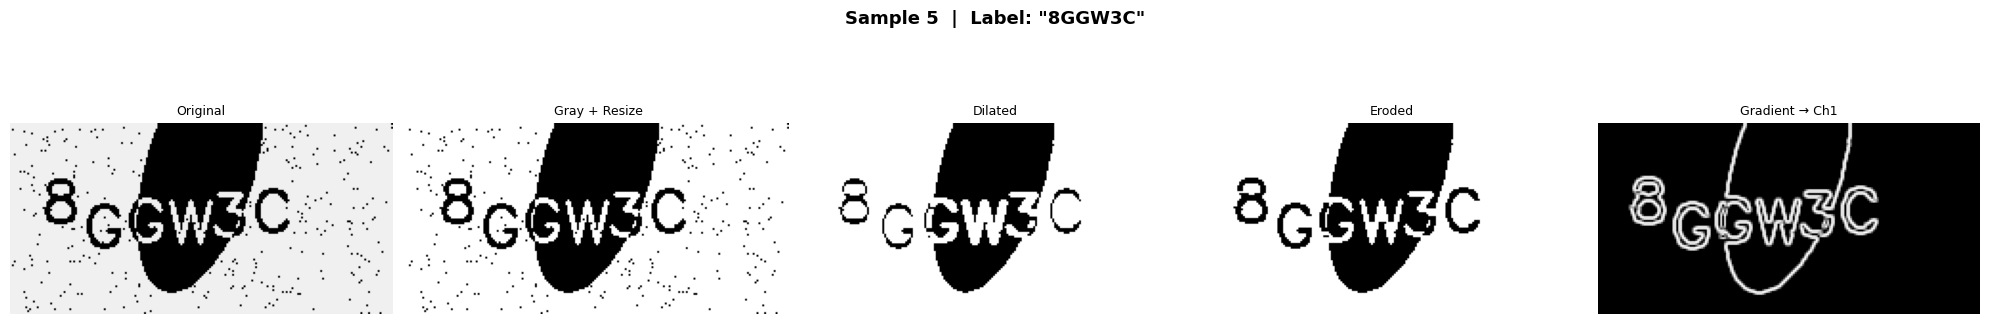

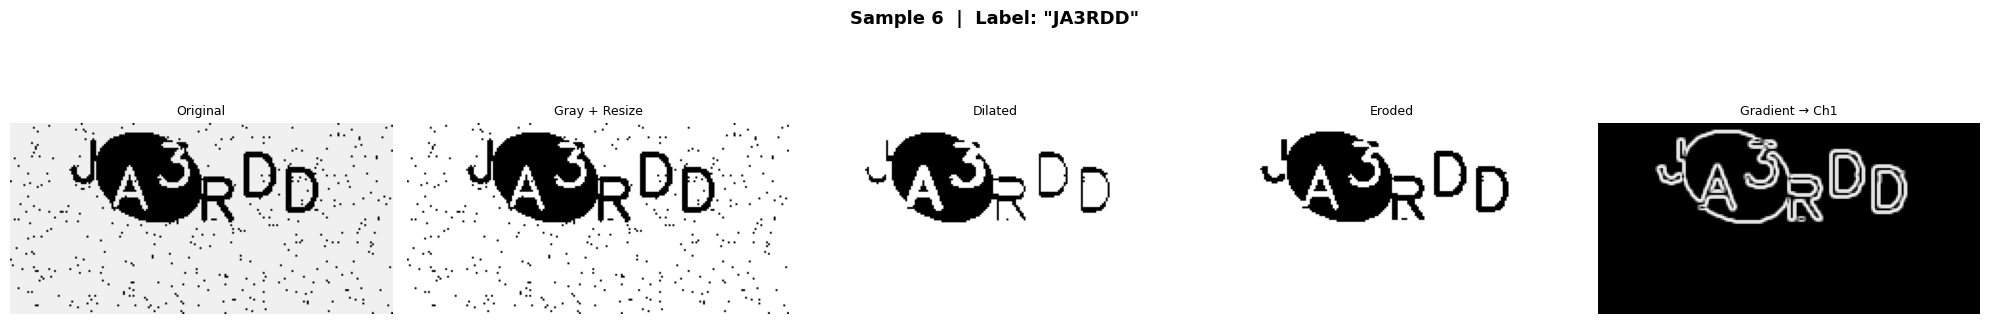

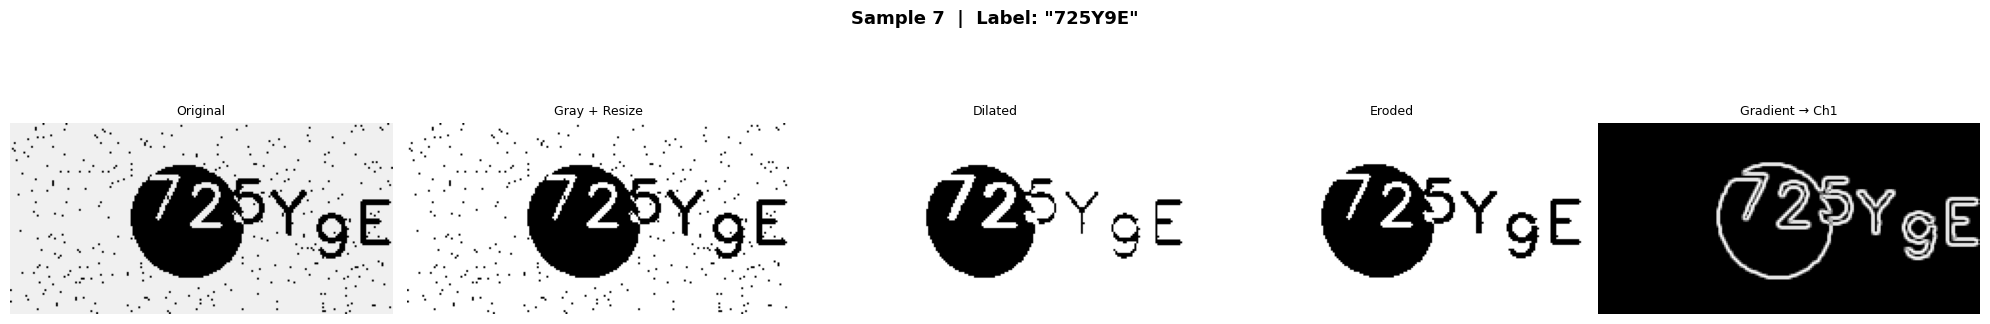

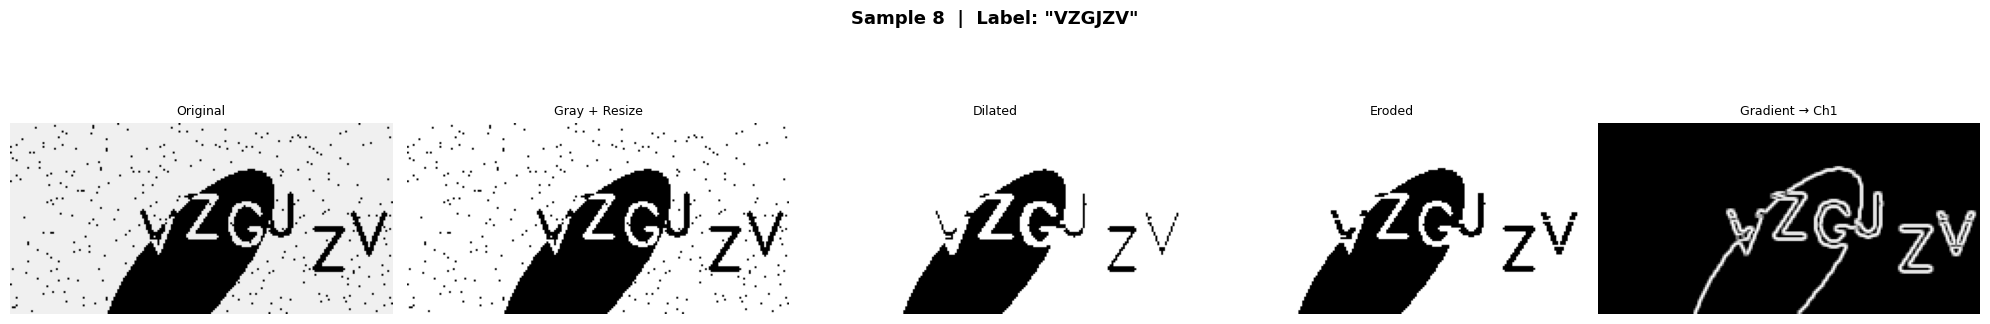

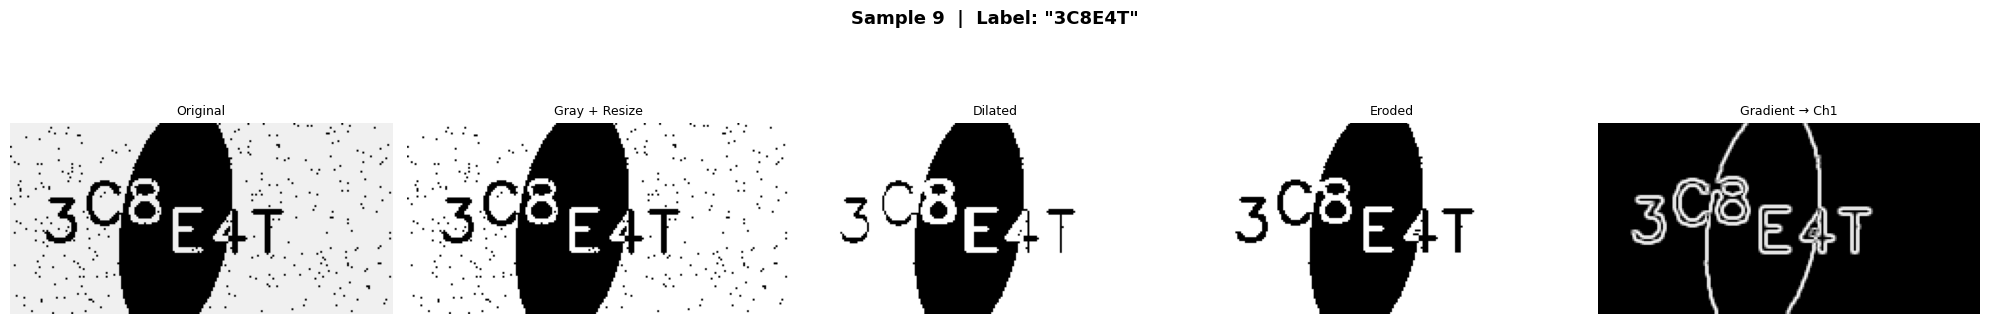

In [ ]:
visualize_pipeline(val_dataset, indices=[i for i in range(0,10)])


## 10. Inspect the Two Channels That Feed the Model

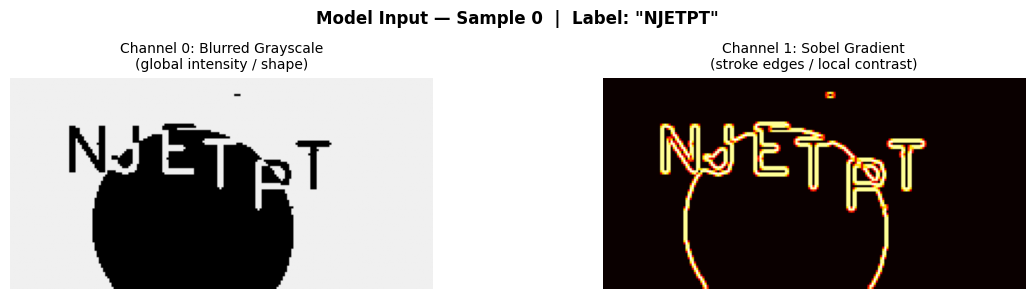

Tensor shape : torch.Size([2, 100, 200])  |  dtype : torch.float32
Ch0 range    : [0.000, 0.941]
Ch1 range    : [0.000, 1.000]


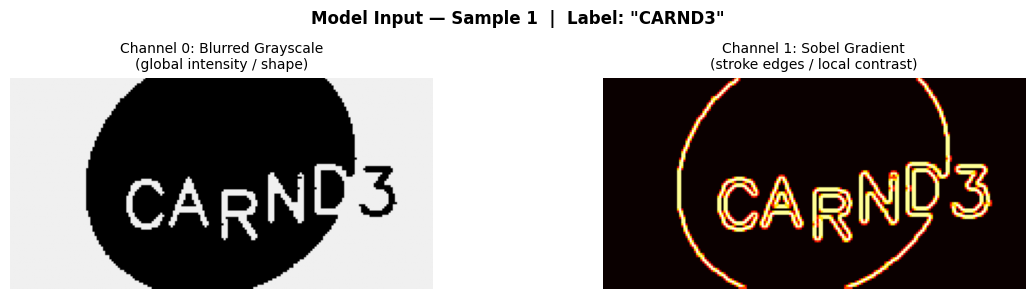

Tensor shape : torch.Size([2, 100, 200])  |  dtype : torch.float32
Ch0 range    : [0.000, 0.941]
Ch1 range    : [0.000, 1.000]


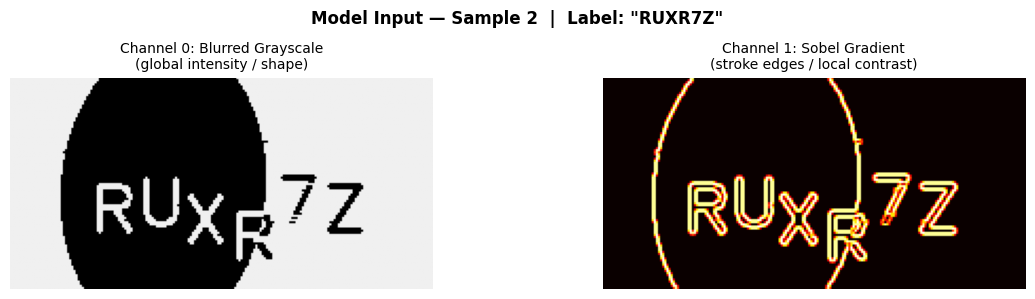

Tensor shape : torch.Size([2, 100, 200])  |  dtype : torch.float32
Ch0 range    : [0.000, 0.941]
Ch1 range    : [0.000, 1.000]


In [ ]:
def show_two_channels(dataset: RawOCRDataset, idx: int = 0):
    sample = dataset[idx]
    img    = sample['image']   # (2, H, W) float32

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(
        f'Model Input — Sample {idx}  |  Label: "{sample["label"]}"',
        fontsize=12, fontweight='bold'
    )

    axes[0].imshow(img[0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Channel 0: Blurred Grayscale\n(global intensity / shape)', fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(img[1].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('Channel 1: Sobel Gradient\n(stroke edges / local contrast)', fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Tensor shape : {img.shape}  |  dtype : {img.dtype}")
    print(f"Ch0 range    : [{img[0].min():.3f}, {img[0].max():.3f}]")
    print(f"Ch1 range    : [{img[1].min():.3f}, {img[1].max():.3f}]")


for i in range(3):
    show_two_channels(val_dataset, idx=i)


## 11. Dataset Statistics

Label length stats:
count    20000.000000
mean         6.000250
std          0.025495
min          6.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          9.000000


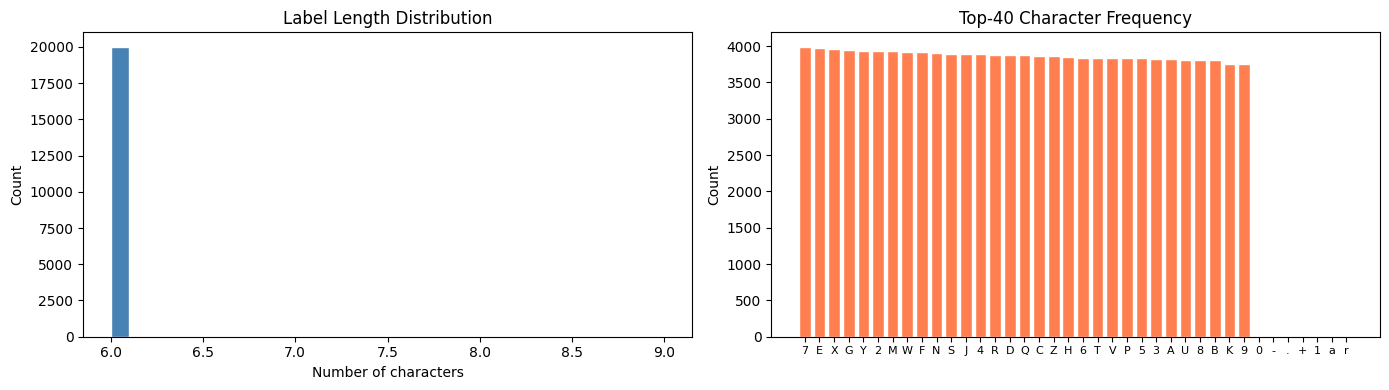


Vocabulary size : 38 unique characters
All chars       : +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar


In [ ]:
df_labels = pd.read_csv(TRAIN_LABEL_CSV)
df_labels['length'] = df_labels['text'].astype(str).str.len()

print("Label length stats:")
print(df_labels['length'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_labels['length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Label Length Distribution', fontsize=12)
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Count')


all_chars = ''.join(df_labels['text'].astype(str).tolist())
from collections import Counter
char_counts = Counter(all_chars)
chars, freqs = zip(*sorted(char_counts.items(), key=lambda x: -x[1])[:40])
axes[1].bar(range(len(chars)), freqs, color='coral', edgecolor='white')
axes[1].set_xticks(range(len(chars)))
axes[1].set_xticklabels(chars, fontsize=8)
axes[1].set_title('Top-40 Character Frequency', fontsize=12)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nVocabulary size : {len(char_counts)} unique characters")
print(f"All chars       : {''.join(sorted(char_counts.keys()))}")


## 11b. Model Architecture — ResNet-Transformer-CTC OCR Pipeline

This section describes the full end-to-end model used for sequence recognition. The architecture follows the classic **CRNN** paradigm but replaces the recurrent (LSTM/GRU) sequence module with a **Transformer encoder**, giving better parallelism and long-range context modelling.

---

### High-Level Overview

```
Input image (B, 2, 100, 200)
        │
        ▼
┌─────────────────────────────┐
│   Residual CNN Backbone     │  Feature extraction from the 2-channel image
│   (5 stages + HeightFold)   │
└─────────────────────────────┘
        │  (B, 256, 25)  — sequence of 25 column feature vectors
        ▼
┌─────────────────────────────┐
│  Positional Encoding        │  Injects position information into the flat sequence
└─────────────────────────────┘
        │  (25, B, 256)
        ▼
┌─────────────────────────────┐
│  Transformer Encoder        │  N × (Multi-Head Self-Attention + FFN + LayerNorm)
│  (pre-norm, N layers)       │
└─────────────────────────────┘
        │  (25, B, 256)
        ▼
┌─────────────────────────────┐
│  Linear Classifier          │  Projects each time-step to class logits
│  (256 → num_classes)        │
└─────────────────────────────┘
        │  (25, B, num_classes)
        ▼
    log_softmax  →  CTCLoss
```

---

### Residual CNN Backbone

The backbone extracts visual features from the 2-channel input and collapses the height dimension into a fixed-length channel vector, producing a **1-D sequence along the width axis** — one feature vector per image column.


**ResidualBlock** uses a **pre-activation** design (BN → ReLU → Conv) and includes a 1×1 projection shortcut whenever the channel count or stride changes. Dropout2d is applied after the second convolution.

**HeightFoldProjection** flattens the remaining height dimension (H=3) into the channel axis, then uses a pointwise Conv1d to project back to 256. This is equivalent to a learned pooling that respects the channel structure.

---

### Transformer Encoder

The CNN output is interpreted as a sequence of 25 time-steps, each with a 256-dimensional feature vector. The Transformer processes this sequence with full self-attention, allowing every column to attend to every other column — useful for resolving ambiguous characters that depend on context.

Key design choices:

- **Pre-norm** : LayerNorm is applied *before* the attention and FFN sub-layers (rather than after). This stabilises gradient flow in deeper configurations and generally trains faster.
- **Sinusoidal positional encoding**: added to the projected sequence before the encoder. Since self-attention is permutation-invariant, the encoding is essential for the model to reason about character order.
- **Linear input projection**: allows the CNN and Transformer dimensions to be set independently.

---

### CTC Output Head

A single LINEAR LAYER maps each time-step's feature to a distribution over the character vocabulary (including the CTC blank token). SOFTMAX is applied before passing to CTC LOSS.

---


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):

    def __init__(self, in_ch, out_ch, stride=1, dropout_p=0.1):
        super().__init__()

        self.bn1 = nn.BatchNorm2d(in_ch)

        self.conv1 = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_ch)

        self.conv2 = nn.Conv2d(
            out_ch,
            out_ch,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.drop = nn.Dropout2d(dropout_p)

        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_ch,
                    out_ch,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        residual = self.shortcut(x)

        out = F.relu(self.bn1(x), inplace=True)
        out = self.conv1(out)

        out = F.relu(self.bn2(out), inplace=True)
        out = self.conv2(out)

        out = self.drop(out)

        return out + residual

class HeightFoldProjection(nn.Module):
    """
    (B,256,3,W)
        ↓
    (B,768,W)
        ↓
    Conv1d(768→256)
        ↓
    (B,256,W)
    """

    def __init__(self, in_ch=256, height=3):
        super().__init__()

        folded_ch = in_ch * height

        self.proj = nn.Conv1d(
            folded_ch,
            in_ch,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm1d(in_ch)

    def forward(self, x):

        B, C, H, W = x.shape

        x = x.reshape(B, C * H, W)

        x = self.proj(x)

        x = self.bn(x)

        return x

class ResidualCNNBackbone(nn.Module):

    def __init__(self, in_channels=2):

        super().__init__()

        # 100x200 -> 50x100
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 2))
        )

        # 50x100 -> 25x50
        self.stage1 = nn.Sequential(
            ResidualBlock(32, 64, dropout_p=0.1),
            ResidualBlock(64, 64, dropout_p=0.1),
            nn.MaxPool2d((2, 2))
        )

        # 25x50 -> 12x25
        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, dropout_p=0.1),
            ResidualBlock(128, 128, dropout_p=0.1),
            nn.MaxPool2d((2, 2))
        )

        # 12x25 -> 6x25
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, dropout_p=0.2),
            ResidualBlock(256, 256, dropout_p=0.2),
            nn.MaxPool2d((2, 1))
        )

        # 6x25 -> 3x25
        self.stage4 = nn.Sequential(
            ResidualBlock(256, 256, dropout_p=0.2),
            ResidualBlock(256, 256, dropout_p=0.2),
            nn.MaxPool2d((2, 1))
        )

        # H=3 exactly
        self.height_fold = HeightFoldProjection(
            in_ch=256,
            height=3
        )

    def forward(self, x):

        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)

        # (B,256,3,25)

        x = self.height_fold(x)

        # (B,256,25)

        return x



DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ResidualCNNBackbone().to(DEVICE)

dummy = torch.zeros(
    4,
    2,
    100,
    200,
    device=DEVICE
)

with torch.no_grad():
    out = model(dummy)

print("Input :", dummy.shape)
print("Output:", out.shape)

assert out.shape == (4, 256, 25)



Input : torch.Size([4, 2, 100, 200])
Output: torch.Size([4, 256, 25])


## 10. Visualise Feature Maps at Each Stage

In [ ]:
def visualize_feature_stages(dataset: RawOCRDataset, idx: int = 0):

    sample = dataset[idx]
    x = sample['image'].unsqueeze(0).to(DEVICE)

    backbone = ResidualCNNBackbone().to(DEVICE)
    backbone.eval()

    hooks, activations = [], []
    stage_names = ['stem', 'stage1', 'stage2', 'stage3', 'stage4']

    def make_hook(name):
        def hook(module, inp, out):
            activations.append((name, out.detach().cpu()))
        return hook

    for name in stage_names:
        hooks.append(getattr(backbone, name).register_forward_hook(make_hook(name)))

    with torch.no_grad():
        out = backbone(x)

    for h in hooks:
        h.remove()

    fig, axes = plt.subplots(1, len(activations), figsize=(22, 3))
    fig.suptitle(f'Mean Feature Maps per Stage | Label: "{sample["label"]}"', fontsize=12, fontweight='bold')

    for ax, (name, feat) in zip(axes, activations):

        mean_map = feat[0].mean(0).numpy()
        ax.imshow(mean_map, cmap='viridis', aspect='auto')
        ax.set_title(f'{name}\n{tuple(feat.shape[1:])}', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Final output shape: {out.shape}  →  (B=1, C=256, W'=32)")

visualize_feature_stages(val_dataset, idx=0)

In [ ]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding injected into the sequence before
    the Transformer encoder. Gives the model position information
    since self-attention is otherwise permutation-invariant.
    """
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


class TransformerSequenceModel(nn.Module):
    """
    Transformer encoder over the width-axis feature sequence from the CNN backbone.
    """
    def __init__(
        self,
        cnn_out_ch : int = 256,
        d_model    : int = 256,
        nhead      : int = 8,
        num_layers : int = 4,
        dim_ff     : int = 512,
        dropout    : float = 0.1,
        max_len    : int = 512,
    ):
        super().__init__()

        assert d_model % nhead == 0, f"d_model={d_model} must be divisible by nhead={nhead}"


        self.input_proj = nn.Linear(cnn_out_ch, d_model)

        self.pos_enc = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_ff,
            dropout         = dropout,
            batch_first     = False,
            norm_first      = True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = num_layers,
            norm       = nn.LayerNorm(d_model),
        )

    def forward(self, x):
        # (B, C, W') → (W', B, C)
        x = x.permute(2, 0, 1)          # (W', B, C)
        x = self.input_proj(x)          # (W', B, d_model)
        x = self.pos_enc(x)             # (W', B, d_model)
        x = self.transformer(x)         # (W', B, d_model)
        return x

In [ ]:
class OCRModelCTC(nn.Module):

    def __init__(self, num_classes, d_model=256, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.base = OCRModel(num_classes, d_model, nhead, num_layers, dropout)

    def forward(self, x):
        logits = self.base(x)                        # (T, B, num_classes)
        return F.log_softmax(logits, dim=2)          # (T, B, num_classes)


In [ ]:
class OCRFeatureExtractor(nn.Module):
  def __init__(
        self,
        d_model=256,
        nhead=2,
        num_layers=3,
        dropout=0.1,
    ):
        super().__init__()

        self.cnn = ResidualCNNBackbone(in_channels=2)

        self.transformer = TransformerSequenceModel(
            cnn_out_ch=256,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_ff=d_model * 2,
            dropout=dropout,
        )

        self.seq_out_dim = d_model

    def forward(self, x):

        x = self.cnn(x)

        x = self.transformer(x)

        return x

In [ ]:
class OCRModel(nn.Module):
    def __init__(
        self,
        num_classes,
        d_model=256,
        nhead=4,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.feature_extractor = OCRFeatureExtractor(
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout,
        )

        self.classifier = nn.Linear(
            d_model,
            num_classes
        )

    def forward(self, x):

        features = self.feature_extractor(x)

        logits = self.classifier(features)

        return logits

## 12. Training Utilities


In [ ]:
def compute_cer(predictions: List[str], targets: List[str]) -> float:

    total_dist, total_chars = 0, 0
    for pred, target in zip(predictions, targets):
        total_dist  += editdistance.eval(pred, target)
        total_chars += len(target)
    return total_dist / max(total_chars, 1)



def greedy_decode(log_probs: torch.Tensor, charset: Charset) -> List[str]:
    indices = log_probs.argmax(dim=2).permute(1, 0)
    return [charset.decode_indices(seq.tolist()) for seq in indices.cpu().numpy()]

class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_cer  = float('inf')
        self.counter   = 0
        self.should_stop = False

    def step(self, val_cer: float) -> bool:
        if val_cer < self.best_cer - self.min_delta:
            self.best_cer = val_cer
            self.counter  = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

─
def build_optimizer(model: nn.Module, lr=1e-3, weight_decay=1e-4, optimizer_type='adamw'):
    if optimizer_type == 'adamw':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


def build_scheduler(optimizer, warmup_epochs=5, total_epochs=50, min_lr=1e-6):
    warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    cosine = CosineAnnealingLR(optimizer,
                               T_max=max(1, total_epochs - warmup_epochs),
                               eta_min=min_lr)
    return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])


def init_model_weights(model: nn.Module):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d, nn.LayerNorm)):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)




## 13. One-Epoch Train & Validate Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, scaler, criterion, device,
                    charset, grad_clip=5.0, accum_steps=1, mixed_precision=True):
    model.train()
    total_loss, all_preds, all_targets = 0.0, [], []
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Train', leave=False)):
        images     = batch['images'].to(device, non_blocking=True)
        labels     = batch['labels'].to(device)
        label_lens = batch['label_lens'].to(device)
        texts      = batch['texts']

        with autocast(enabled=mixed_precision):
            log_probs = model(images)


        T, B, _ = log_probs.shape
        input_lens = torch.full((B,), T, dtype=torch.long, device=device)
        loss = criterion(log_probs.float(), labels, input_lens, label_lens)
        loss = loss / accum_steps
        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        with torch.no_grad():
            all_preds.extend(greedy_decode(log_probs.detach(), charset))
        all_targets.extend(texts)
        total_loss += loss.item() * accum_steps

    return total_loss / len(loader), compute_cer(all_preds, all_targets)


@torch.no_grad()
def validate(model, loader, criterion, device, charset, mixed_precision=True):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    for batch in tqdm(loader, desc='Val', leave=False):
        images     = batch['images'].to(device, non_blocking=True)
        labels     = batch['labels'].to(device)
        label_lens = batch['label_lens'].to(device)
        texts      = batch['texts']

        with autocast(enabled=mixed_precision):
            log_probs = model(images)

        T, B, _ = log_probs.shape
        input_lens = torch.full((B,), T, dtype=torch.long, device=device)
        loss = criterion(log_probs.float(), labels, input_lens, label_lens)

        all_preds.extend(greedy_decode(log_probs, charset))
        all_targets.extend(texts)
        total_loss += loss.item()

    return total_loss / len(loader), compute_cer(all_preds, all_targets)



## 14. Checkpoint Helpers

In [ ]:
def save_checkpoint(model, optimizer, epoch, best_cer, charset, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_cer' : best_cer,
        'charset'  : charset.chars,
    }, path)


def load_checkpoint(path, model, device, optimizer=None):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt['optimizer'])
    return ckpt



## 14b CTC Loss — How It Works

### The Sequence Alignment Problem

Standard cross-entropy loss requires a one-to-one alignment between output time-steps and target labels. For OCR this is impractical: the number of CNN/Transformer output frames (T=25 here) is not the same as the number of characters in the label, and we do not know which frame corresponds to which character.

**Connectionist Temporal Classification (CTC)** solves this by marginalising over all valid alignments.

---

### Key Concepts

**Blank token (index 0)**  
CTC introduces a special `<blank>` symbol. The model can output blank at any frame — blank means "no character at this position" and is used to separate repeated characters and to fill frames that do not correspond to any label character.

**CTC path → label string**  
A raw output sequence of frame-wise class predictions is called a *path*. A path is collapsed into a label string by two rules applied in order:

1. Merge consecutive **duplicate** tokens.  
2. Remove all **blank** tokens.



Greedy decoding is fast and works well in practice, though it is not guaranteed to find the most probable label string. Beam-search decoding (with or without a language model) can improve accuracy at the cost of more computation.

---
---

### In This Notebook

```python
criterion = nn.CTCLoss(blank=charset.blank_idx, reduction='mean', zero_infinity=True)
```


## 15. Instantiate Model & Training Components

In [ ]:
EPOCHS         = 50
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
WARMUP_EPOCHS  = 5
MIN_LR         = 1e-6
GRAD_CLIP      = 5.0
ACCUM_STEPS    = 1
MIXED_PREC     = True
EARLY_STOP_PAT = 10
CKPT_DIR       = 'outputs/checkpoints'
CKPT_PATH      = f'{CKPT_DIR}/best.pt'


model = OCRModelCTC(
    num_classes = charset.num_classes,
    d_model     = 256,
    nhead       = 4,
    num_layers  = 2,
    dropout     = 0.1,
).to(device)
init_model_weights(model)

─
criterion = nn.CTCLoss(blank=charset.blank_idx, reduction='mean', zero_infinity=True)

─
optimizer = build_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = build_scheduler(optimizer,
                             warmup_epochs=WARMUP_EPOCHS,
                             total_epochs=EPOCHS,
                             min_lr=MIN_LR)
scaler    = GradScaler(enabled=MIXED_PREC)
early_stopping = EarlyStopping(patience=EARLY_STOP_PAT)


with torch.no_grad():
    dummy = torch.zeros(2, 2, 100, 200, device=device)
    out   = model(dummy)
    T, B, C = out.shape
    print(f"Model output shape : (T={T}, B={B}, num_classes={C})")
    assert C == charset.num_classes

print(f"\nModel params : {sum(p.numel() for p in model.parameters()):,}")
print(f"CTC blank idx: {charset.blank_idx}")
print(f"Vocab size   : {charset.num_classes}")
print("Training components ready ✓")


## 16. Training Loop

In [ ]:
history  = {'train_loss': [], 'val_loss': [], 'train_cer': [], 'val_cer': [], 'lr': []}
best_cer = float('inf')
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"Starting training for {EPOCHS} epochs")
print(f"Checkpoint -> {CKPT_PATH}")
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_cer = train_one_epoch(
        model, train_loader, optimizer, scaler, criterion,
        device, charset,
        grad_clip=GRAD_CLIP, accum_steps=ACCUM_STEPS, mixed_precision=MIXED_PREC,
    )
    val_loss, val_cer = validate(
        model, val_loader, criterion, device, charset, mixed_precision=MIXED_PREC,
    )
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_cer'].append(train_cer)
    history['val_cer'].append(val_cer)
    history['lr'].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f}  train_cer={train_cer:.4f} | "
        f"val_loss={val_loss:.4f}  val_cer={val_cer:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_cer < best_cer:
        best_cer = val_cer
        save_checkpoint(model, optimizer, epoch, best_cer, charset, CKPT_PATH)
        print(f"  ↳ New best CER {best_cer:.4f} saved to {CKPT_PATH}")

    if early_stopping.step(val_cer):
        print(f"Early stopping at epoch {epoch}.  Best val_cer={best_cer:.4f}")
        break

print('=' * 65)
print(f"Training complete.  Best val_cer = {best_cer:.4f}")


## 17. Results & Qualitative Evaluation

In [ ]:
if os.path.exists(CKPT_PATH):
    load_checkpoint(CKPT_PATH, model, device)
    print(f"Loaded best checkpoint (CER={best_cer:.4f})")
model.eval()


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_cer'], label='train')
axes[1].plot(history['val_cer'],   label='val')
axes[1].axhline(0.2, color='r', linestyle='--', label='target 0.2')
axes[1].set_title('CER'); axes[1].legend()

axes[2].plot(history['lr'])
axes[2].set_title('Learning Rate')
plt.tight_layout(); plt.show()


sample_batch = next(iter(val_loader))
with torch.no_grad():
    log_probs = model(sample_batch['images'].to(device))
preds = greedy_decode(log_probs, charset)

print("\nSample predictions (first 10):")
for fn, pred, target in zip(sample_batch['paths'][:10], preds[:10], sample_batch['texts'][:10]):
    ok = 'OK' if pred == target else 'X '
    print(f"  [{ok}]  pred='{pred}'  target='{target}'  file={Path(fn).name}")


## 18. Test Inference & Submission CSV

In [ ]:

test_dataset = RawOCRDataset(
    image_dir   = TEST_IMAGE_DIR,
    label_file  = None,
    target_size = (100, 200),
    transform   = None,
)

def collate_fn_test(batch):
    images = torch.stack([b['image'] for b in batch])
    paths  = [b['path'] for b in batch]
    return {'images': images, 'paths': paths}

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = 0,
    collate_fn  = collate_fn_test,
)

all_filenames, all_predictions = [], []
model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Predict test'):
        log_probs = model(batch['images'].to(device))
        preds     = greedy_decode(log_probs, charset)
        all_filenames.extend([Path(p).name for p in batch['paths']])
        all_predictions.extend(preds)

SUBMISSION_DIR = 'outputs/submissions'
os.makedirs(SUBMISSION_DIR, exist_ok=True)
submission_path = f'{SUBMISSION_DIR}/submission.csv'
pd.DataFrame({'image': all_filenames, 'prediction': all_predictions}).to_csv(
    submission_path, index=False
)
print(f"\nSubmission saved: {submission_path}")
print("Sample predictions:", all_predictions[:5])
